# EEG_22_v2 — Firma Spettrale per Sessione

**Domanda**: la firma alpha↑ di C0 osservata in EEG_22 §11 è stabile tra sessioni 1-5, o emerge solo nelle sessioni tarde (artefatto di apprendimento/abituazione)?

**Setup**: top-10 C0/C1 per bAcc (stesso di EEG_22 §10). Inference su ogni sessione separatamente. Per ogni sessione: MW + Cohen's d corretti vs sbagliati.

- Firma stabile → proprietà strutturale del soggetto
- Firma cresce con la sessione → effetto apprendimento

## §1 — Setup (identico a EEG_22)

In [1]:
import json, logging, re
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy import signal
from scipy.stats import mannwhitneyu
from sklearn.metrics import balanced_accuracy_score
from tqdm.auto import tqdm

logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)-8s %(message)s', datefmt='%H:%M:%S')
log = logging.getLogger('eeg22v2')

project_root = next((p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / '.git').exists()), Path.cwd())
FIG_DIR  = project_root / 'figures'; FIG_DIR.mkdir(exist_ok=True)
CKPT_13B = project_root / 'models' / 'eeg13b_200e'

N_CHANNELS=61; N_SAMPLES=384; N_CLASSES=4; CLUSTER_SCHEME='concr4'
K_WINDOWS=8; N_EDGES=16; D_MODEL=64; HIDDEN=128; N_LAYERS=2; DROPOUT=0.5
T_WIN=N_SAMPLES//K_WINDOWS; FS=256; DATA_METRIC='abs_pcc'
CLUSTER_NAMES={0:'Fronto-motor (C0)',1:'Fronto-occipital (C1)'}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,50)}
device=torch.device('cpu')

with open(project_root/'configs'/'label_schemes'/'label2idx.json') as f:
    WORD2LABEL=json.load(f)
with open(project_root/'configs'/'label_schemes'/f'labelid2cluster_{CLUSTER_SCHEME}.json') as f:
    _raw=json.load(f); label2cluster={int(k):int(v) for k,v in _raw.items()}
_labels_path = project_root / 'configs' / 'eeg16b_cluster_labels.json'
if _labels_path.exists():
    _cd = json.loads(_labels_path.read_text())
    SUBJ_CLUSTER = {s: l for s, l in zip(_cd['subj_ids'], _cd['labels'])}
    log.info(f'Cluster labels: C0={sum(v==0 for v in SUBJ_CLUSTER.values())}  C1={sum(v==1 for v in SUBJ_CLUSTER.values())}')
else:
    log.warning('eeg16b_cluster_labels.json non trovato'); SUBJ_CLUSTER = {}

_PAT = re.compile(r'^P(\d+)_S(\d+)$')
subj_sess = defaultdict(lambda: defaultdict(list))
_root = project_root/'data'/f'hypergraphs_pruned_{DATA_METRIC}'
for p in sorted(_root.rglob('trial_*.pt')):
    m = _PAT.match(p.parent.name)
    if m: subj_sess[int(m.group(1))][int(m.group(2))].append(p)
log.info(f'Soggetti: {len(subj_sess)}')

15:34:56 INFO     Cluster labels: C0=36  C1=37


15:34:56 INFO     Soggetti: 74


## §2 — DHSLP (identico a EEG_22)

In [2]:
class HGNNConv(nn.Module):
    def __init__(self,in_dim,out_dim):
        super().__init__()
        self.weight=nn.Parameter(torch.empty(in_dim,out_dim))
        self.bias=nn.Parameter(torch.zeros(out_dim))
        nn.init.xavier_uniform_(self.weight)
    def forward(self,x,H):
        Dv=H.sum(dim=2,keepdim=True).clamp(min=1e-6)
        De=H.sum(dim=1).clamp(min=1e-6).unsqueeze(2)
        Ht=H.transpose(1,2); x_norm=x/Dv
        step1=torch.bmm(Ht,x_norm); step2=step1/De
        return torch.bmm(H,step2)@self.weight+self.bias

class DHSLP(nn.Module):
    def __init__(self,n_nodes=N_CHANNELS,T_win=T_WIN,K=K_WINDOWS,n_edges=N_EDGES,
                 d_model=D_MODEL,hidden=HIDDEN,n_classes=N_CLASSES,n_layers=N_LAYERS,dropout=DROPOUT):
        super().__init__()
        self.K=K; self.T_win=T_win; self.d_model=d_model
        self.E=nn.Parameter(torch.randn(n_edges,d_model)*0.01)
        self.pos_enc=nn.Parameter(torch.randn(n_nodes,d_model)*0.01)
        self.node_proj=nn.Sequential(nn.Linear(T_win,d_model),nn.LayerNorm(d_model),nn.ELU())
        dims=[d_model]+[hidden]*n_layers
        self.convs=nn.ModuleList([HGNNConv(dims[i],dims[i+1]) for i in range(n_layers)])
        self.bns=nn.ModuleList([nn.BatchNorm1d(hidden) for _ in range(n_layers)])
        self.drop=nn.Dropout(dropout); self.clf=nn.Linear(hidden,n_classes)
    def build_dynamic_H(self,feat):
        scores=torch.matmul(feat,self.E.T)/(self.d_model**0.5)
        return torch.softmax(scores,dim=-1)
    def forward(self,x):
        B,N,T=x.shape
        wins=x.reshape(B,N,self.K,self.T_win).permute(0,2,1,3).reshape(B*self.K,N,self.T_win)
        feat=self.node_proj(wins)+self.pos_enc.unsqueeze(0)
        H=self.build_dynamic_H(feat); h=feat
        for conv,bn in zip(self.convs,self.bns):
            h=conv(h,H)
            h=h.reshape(B*self.K*N,-1); h=bn(h); h=h.reshape(B*self.K,N,-1)
            h=F.elu(h); h=self.drop(h)
        h=h.mean(dim=1).reshape(B,self.K,-1).mean(dim=1)
        return self.clf(h)

def load_model(sid):
    ckpt_path=CKPT_13B/f'P{sid:03d}.pt'
    if not ckpt_path.exists(): return None
    ck=torch.load(ckpt_path,map_location=device,weights_only=False)
    m=DHSLP().to(device); m.load_state_dict(ck['state_dict']); m.eval(); return m

log.info('DHSLP pronto.')

15:34:56 INFO     DHSLP pronto.


## §3 — Top-10 per bAcc

In [3]:
subj_bacc={}
for p in sorted(CKPT_13B.glob('P*.pt')):
    sid=int(p.stem[1:]); ck=torch.load(p,map_location='cpu',weights_only=False)
    subj_bacc[sid]=float(ck['test_bacc'])
SEL_N=10
c0_ranked=sorted([s for s in subj_bacc if SUBJ_CLUSTER.get(s)==0],key=lambda s:subj_bacc[s])
c1_ranked=sorted([s for s in subj_bacc if SUBJ_CLUSTER.get(s)==1],key=lambda s:subj_bacc[s])
TOP_C0=c0_ranked[::-1][:SEL_N]; TOP_C1=c1_ranked[::-1][:SEL_N]
TOPBACC_SUBJ=TOP_C0+TOP_C1
print(f'TOP C0: {[f"P{s:03d}({subj_bacc[s]:.3f})" for s in TOP_C0]}')
print(f'TOP C1: {[f"P{s:03d}({subj_bacc[s]:.3f})" for s in TOP_C1]}')

TOP C0: ['P016(0.325)', 'P033(0.316)', 'P042(0.312)', 'P062(0.297)', 'P039(0.296)', 'P019(0.294)', 'P053(0.291)', 'P067(0.290)', 'P004(0.271)', 'P026(0.267)']
TOP C1: ['P070(0.393)', 'P006(0.352)', 'P032(0.323)', 'P051(0.315)', 'P013(0.314)', 'P011(0.313)', 'P036(0.312)', 'P052(0.303)', 'P054(0.294)', 'P020(0.268)']


## §4 — Inference per sessione

Per ogni top-soggetto, esegue inference su OGNI sessione (non solo l'ultima).
Record taggati con `sess_id`.

In [4]:
def band_power(x_np, fs=FS):
    freqs,psd=signal.welch(x_np,fs=fs,nperseg=min(128,x_np.shape[1]),axis=1)
    return {band:psd[:,(freqs>=lo)&(freqs<hi)].mean(axis=1) for band,(lo,hi) in BANDS.items()}

def run_inference_session(subj_id, model, sess_id):
    if sess_id not in subj_sess.get(subj_id,{}): return []
    paths=subj_sess[subj_id][sess_id]; records=[]
    with torch.no_grad():
        for p in paths:
            d=torch.load(p,weights_only=False)
            x=d['x'].float()
            y_word=int(d['y'].squeeze()) if isinstance(d['y'],torch.Tensor) else int(d['y'])
            y_true=label2cluster.get(y_word)
            if y_true is None: continue
            x_norm=(x-x.mean(dim=1,keepdim=True))/(x.std(dim=1,keepdim=True)+1e-6)
            logits=model(x_norm.unsqueeze(0).to(device))
            probs=F.softmax(logits,dim=1).squeeze().cpu().numpy()
            y_pred=int(probs.argmax())
            records.append({'subj_id':subj_id,'sess_id':sess_id,
                            'y_true':y_true,'y_pred':y_pred,'correct':int(y_true==y_pred),
                            'bp':band_power(x.numpy())})
    return records

ALL_SESS_RECORDS=[]
for sid in tqdm(TOPBACC_SUBJ, desc='Inference sessioni'):
    model=load_model(sid)
    if model is None: continue
    for sess_id in sorted(subj_sess[sid].keys()):
        recs=run_inference_session(sid,model,sess_id)
        ALL_SESS_RECORDS.extend(recs)
        if recs:
            bacc=balanced_accuracy_score([r['y_true'] for r in recs],[r['y_pred'] for r in recs])
            log.info(f'P{sid:03d} S{sess_id} [{CLUSTER_NAMES.get(SUBJ_CLUSTER.get(sid,-1),"?")}] — {len(recs)} trial bAcc={bacc:.4f}')
    del model

df_all=pd.DataFrame([{k:v for k,v in r.items() if k!='bp'} for r in ALL_SESS_RECORDS])
print(f'\nRecord totali: {len(ALL_SESS_RECORDS)}')
print(df_all.groupby(['sess_id','correct']).size().unstack(fill_value=0))

Inference sessioni:   0%|          | 0/20 [00:00<?, ?it/s]

15:34:56 INFO     P016 S1 [Fronto-motor (C0)] — 110 trial bAcc=0.4269


15:34:56 INFO     P016 S2 [Fronto-motor (C0)] — 110 trial bAcc=0.5367


15:34:57 INFO     P016 S3 [Fronto-motor (C0)] — 110 trial bAcc=0.2367


15:34:57 INFO     P016 S4 [Fronto-motor (C0)] — 110 trial bAcc=0.2547


...

15:35:14 INFO     P020 S3 [Fronto-occipital (C1)] — 110 trial bAcc=0.4256


15:35:14 INFO     P020 S4 [Fronto-occipital (C1)] — 110 trial bAcc=0.4678


15:35:15 INFO     P020 S5 [Fronto-occipital (C1)] — 110 trial bAcc=0.2359


15:35:15 INFO     P020 S6 [Fronto-occipital (C1)] — 110 trial bAcc=0.2714



Record totali: 10532
correct     0    1
sess_id           
1        1171  958
2        1255  926
3        1338  846
4        1523  551
5        1341  513
6          81   29


## §5 — BP diff per sessione + plot

In [5]:
def compute_bp_diff_group(records, cluster_id):
    recs=[r for r in records if SUBJ_CLUSTER.get(r['subj_id'])==cluster_id]
    ok=[r for r in recs if r['correct']==1]
    no=[r for r in recs if r['correct']==0]
    if len(ok)<5 or len(no)<5: return None
    cohd={}; nsig={}
    for band in BANDS:
        bp_ok=np.stack([r['bp'][band] for r in ok])
        bp_no=np.stack([r['bp'][band] for r in no])
        cd=np.zeros(N_CHANNELS); pv=np.ones(N_CHANNELS)
        for ch in range(N_CHANNELS):
            _,p=mannwhitneyu(bp_ok[:,ch],bp_no[:,ch],alternative='two-sided')
            pv[ch]=p
            ps=np.sqrt((bp_ok[:,ch].std()**2+bp_no[:,ch].std()**2)/2+1e-12)
            cd[ch]=(bp_ok[:,ch].mean()-bp_no[:,ch].mean())/ps
        cohd[band]=cd; nsig[band]=int((pv<0.05).sum())
    return {'cohd':cohd,'nsig':nsig,'n_ok':len(ok),'n_no':len(no)}

all_sess=sorted(df_all['sess_id'].unique())
SESS_RESULTS={cl:{} for cl in [0,1]}
for sess_id in all_sess:
    sess_recs=[r for r in ALL_SESS_RECORDS if r['sess_id']==sess_id]
    for cl in [0,1]:
        SESS_RESULTS[cl][sess_id]=compute_bp_diff_group(sess_recs,cl)

# Riepilogo testo
print(f'{"":8}' + ' '.join([f'S{s}:alpha/theta' for s in all_sess]))
for cl in [0,1]:
    row=f'C{cl}      '
    band='alpha' if cl==0 else 'theta'
    for s in all_sess:
        r=SESS_RESULTS[cl][s]
        row += f'  {r["nsig"][band]:2}/61     ' if r else '  N/A       '
    print(row)

        S1:alpha/theta S2:alpha/theta S3:alpha/theta S4:alpha/theta S5:alpha/theta S6:alpha/theta
C0        20/61        5/61        7/61        3/61        6/61       N/A       
C1        23/61       12/61       20/61       20/61        1/61        1/61     


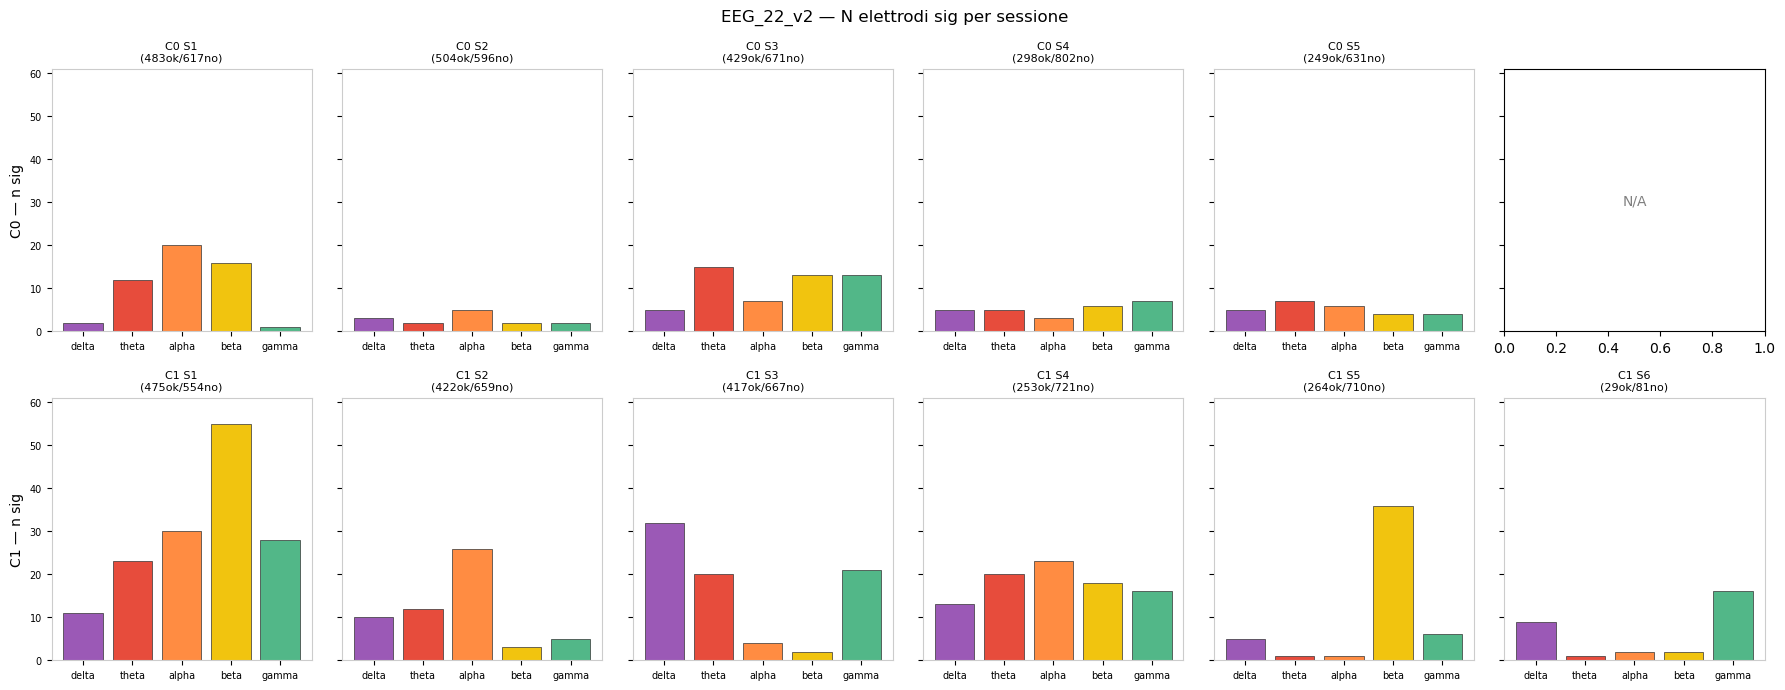

In [6]:
# === Plot barplot n_sig per sessione per banda ===
band_colors={'delta':'#9B59B6','theta':'#E74C3C','alpha':'#FF8C42','beta':'#F1C40F','gamma':'#52B788'}
fig,axes=plt.subplots(2,len(all_sess),figsize=(3*len(all_sess),7),sharey='row')
fig.patch.set_facecolor('white')
for cl in [0,1]:
    for j,sess_id in enumerate(all_sess):
        ax=axes[cl][j]; ax.set_facecolor('white')
        r=SESS_RESULTS[cl][sess_id]
        if r is None:
            ax.text(0.5,0.5,'N/A',ha='center',va='center',transform=ax.transAxes,color='gray'); continue
        bars=list(BANDS.keys()); vals=[r['nsig'][b] for b in bars]
        ax.bar(bars,vals,color=[band_colors[b] for b in bars],edgecolor='#333',linewidth=0.5)
        ax.set_ylim(0,61)
        ax.set_title(f'C{cl} S{sess_id}\n({r["n_ok"]}ok/{r["n_no"]}no)',fontsize=8,color='black')
        ax.tick_params(colors='black',labelsize=7)
        if j==0: ax.set_ylabel(f'C{cl} — n sig',color='black')
        for sp in ax.spines.values(): sp.set_edgecolor('#CCCCCC')
plt.suptitle('EEG_22_v2 — N elettrodi sig per sessione',color='black',fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR/'eeg22v2_nsig_per_session.png',dpi=150,bbox_inches='tight',facecolor='white')
plt.show()

## §6 — Per-soggetto: alpha Cohen's d per sessione (C0)

Per ogni top-C0 soggetto: Cohen's d della banda alpha sugli elettrodi chiave (F6, FT8, C3, CP2, P5 da EEG_22 §11) in ciascuna sessione.

- Linee piatte → firma stabile (non è apprendimento)
- Linee crescenti → firma emerge con la pratica

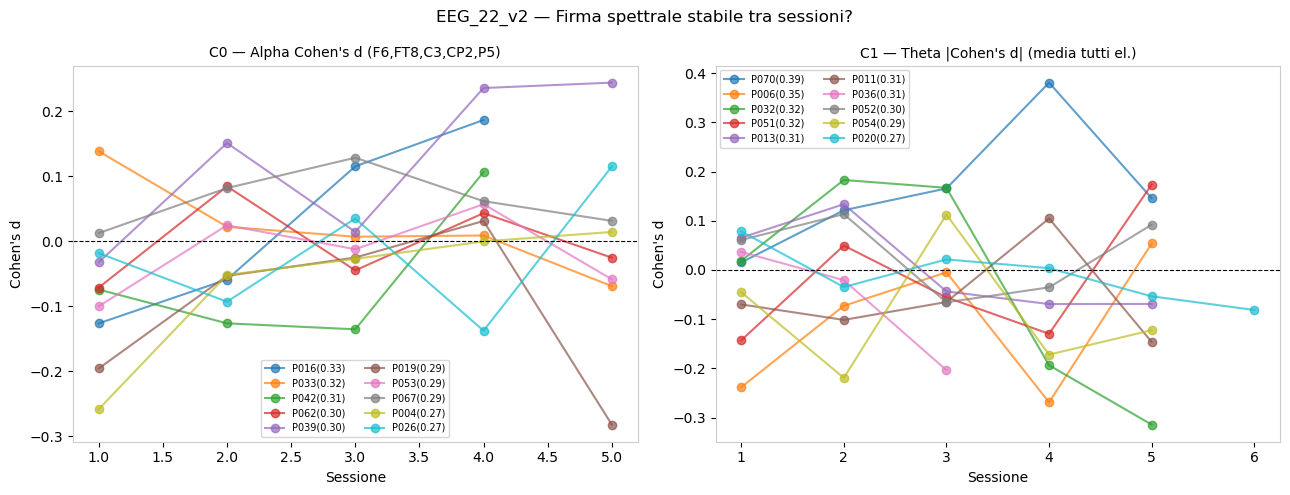

In [7]:
CHAN_NAMES_MNE=['A1','AF7','AF3','Fp1','Fp2','AF4','AF8','A2',
    'F7','F5','F3','F1','F2','F4','F6','F8',
    'FT7','FC5','FC3','FC1','FC2','FC4','FC6','FT8',
    'T7','C5','C3','C1','C2','C4','C6','T8',
    'TP7','CP5','CP3','CP1','CP2','CP4','CP6','TP8',
    'P7','P5','P3','P1','P2','P4','P6','P8',
    'FPz','PO7','PO3','O1','O2','PO4','PO8','Oz',
    'AFz','Fz','FCz','Cz','CPz']
ELEC_IDX={n:i for i,n in enumerate(CHAN_NAMES_MNE)}
KEY_ALPHA=['F6','FT8','C3','CP2','P5']
KEY_IDX=[ELEC_IDX[e] for e in KEY_ALPHA if e in ELEC_IDX]

fig,axes=plt.subplots(1,2,figsize=(13,5)); fig.patch.set_facecolor('white')
for ax,(cl,subjs,band,title) in zip(axes,[
    (0,TOP_C0,'alpha','C0 — Alpha Cohen\'s d (F6,FT8,C3,CP2,P5)'),
    (1,TOP_C1,'theta','C1 — Theta |Cohen\'s d| (media tutti el.)'),
]):
    ax.set_facecolor('white')
    for sid in subjs:
        d_per_sess=[]
        for sess_id in all_sess:
            recs=[r for r in ALL_SESS_RECORDS if r['subj_id']==sid and r['sess_id']==sess_id]
            ok=[r for r in recs if r['correct']==1]
            no=[r for r in recs if r['correct']==0]
            if len(ok)<3 or len(no)<3: d_per_sess.append(float('nan')); continue
            if cl==0:
                bp_ok=np.stack([r['bp'][band][KEY_IDX] for r in ok])
                bp_no=np.stack([r['bp'][band][KEY_IDX] for r in no])
            else:
                bp_ok=np.stack([r['bp'][band] for r in ok])
                bp_no=np.stack([r['bp'][band] for r in no])
            ps=np.sqrt((bp_ok.std(0)**2+bp_no.std(0)**2)/2+1e-12)
            cd=np.nanmean((bp_ok.mean(0)-bp_no.mean(0))/ps)
            d_per_sess.append(float(cd))
        ax.plot(all_sess,d_per_sess,'o-',alpha=0.7,label=f'P{sid:03d}({subj_bacc[sid]:.2f})')
    ax.axhline(0,color='black',lw=0.8,ls='--')
    ax.set_xlabel('Sessione',color='black'); ax.set_ylabel("Cohen's d",color='black')
    ax.set_title(title,color='black',fontsize=10); ax.tick_params(colors='black')
    ax.legend(fontsize=7,ncol=2); 
    for sp in ax.spines.values(): sp.set_edgecolor('#CCCCCC')
plt.suptitle('EEG_22_v2 — Firma spettrale stabile tra sessioni?',color='black',fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR/'eeg22v2_alpha_per_session.png',dpi=150,bbox_inches='tight',facecolor='white')
plt.show()

## §7 — Verdict

In [8]:
print('='*60)
print('EEG_22_v2 — VERDICT')
print('='*60)
for cl in [0,1]:
    band='alpha' if cl==0 else 'theta'
    vals=[SESS_RESULTS[cl][s]['nsig'][band] for s in all_sess if SESS_RESULTS[cl].get(s)]
    if not vals: continue
    print(f'\nC{cl} ({CLUSTER_NAMES[cl]}) — banda {band}:')
    print(f'  n_sig per sessione: {vals}')
    print(f'  min={min(vals)}  max={max(vals)}  range={max(vals)-min(vals)}')
    if max(vals)-min(vals) <= 4:
        print('  → STABILE — firma non è artefatto apprendimento')
    elif vals[-1] > vals[0]*1.5:
        print('  → CRESCENTE — possibile effetto abituazione/apprendimento')
    else:
        print('  → VARIABILE — fluttuazione moderata')

EEG_22_v2 — VERDICT

C0 (Fronto-motor (C0)) — banda alpha:
  n_sig per sessione: [20, 5, 7, 3, 6]
  min=3  max=20  range=17
  → VARIABILE — fluttuazione moderata

C1 (Fronto-occipital (C1)) — banda theta:
  n_sig per sessione: [23, 12, 20, 20, 1, 1]
  min=1  max=23  range=22
  → VARIABILE — fluttuazione moderata


## §8 — bAcc per sessione (test ipotesi fatica)

Se i soggetti sono più concentrati in S1 e si stancano nelle sessioni successive,
ci aspettiamo un calo monotono di bAcc da S1 a S5.
Se bAcc è stabile → il crollo alpha non è un confound di fatica.

/tmp/ipykernel_361534/2296230739.py:24: RuntimeWarning: Mean of empty slice
  mean_bacc = np.nanmean(all_bacc, axis=0)


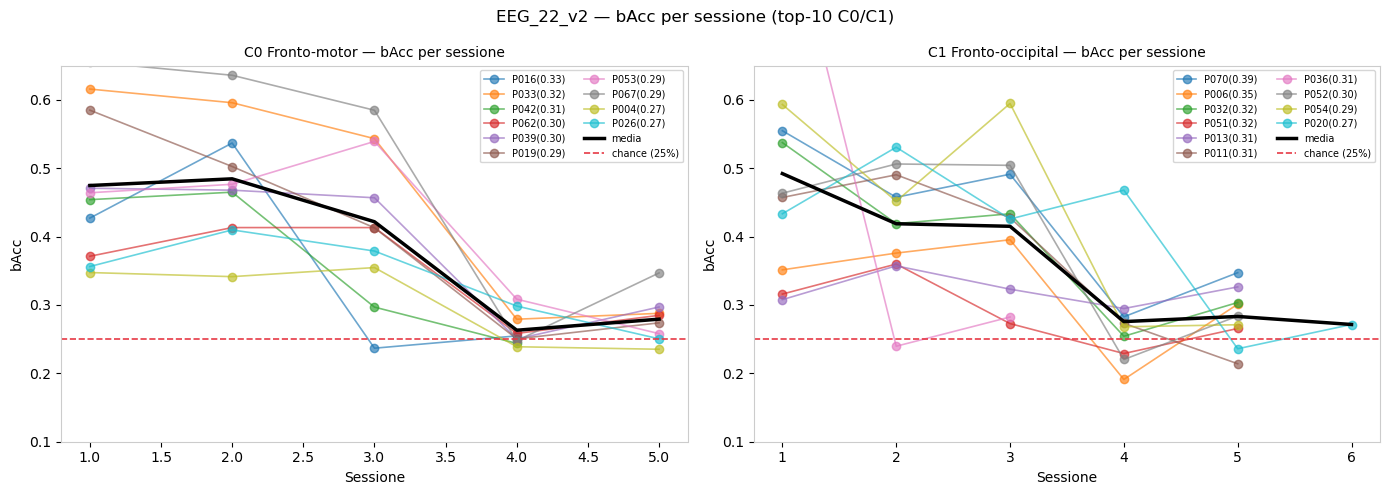

Figura salvata: eeg22v2_bacc_per_session.png


In [9]:
# §8 — bAcc per sessione per soggetto
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')

for ax, (cl, subjs, title) in zip(axes, [
    (0, TOP_C0, 'C0 Fronto-motor — bAcc per sessione'),
    (1, TOP_C1, 'C1 Fronto-occipital — bAcc per sessione'),
]):
    ax.set_facecolor('white')
    all_bacc = []
    for sid in subjs:
        bacc_sess = []
        for sess_id in all_sess:
            recs = [r for r in ALL_SESS_RECORDS if r['subj_id'] == sid and r['sess_id'] == sess_id]
            if len(recs) < 5:
                bacc_sess.append(float('nan'))
                continue
            ba = balanced_accuracy_score([r['y_true'] for r in recs], [r['y_pred'] for r in recs])
            bacc_sess.append(ba)
        ax.plot(all_sess, bacc_sess, 'o-', alpha=0.65, lw=1.2,
                label=f'P{sid:03d}({subj_bacc[sid]:.2f})')
        all_bacc.append(bacc_sess)

    mean_bacc = np.nanmean(all_bacc, axis=0)
    ax.plot(all_sess, mean_bacc, 'k-', lw=2.5, label='media', zorder=5)
    ax.axhline(0.25, color='#E63946', lw=1.2, ls='--', label='chance (25%)')

    ax.set_xlabel('Sessione', color='black')
    ax.set_ylabel('bAcc', color='black')
    ax.set_title(title, color='black', fontsize=10)
    ax.tick_params(colors='black')
    ax.set_ylim(0.10, 0.65)
    ax.legend(fontsize=7, ncol=2)
    for sp in ax.spines.values(): sp.set_edgecolor('#CCCCCC')

plt.suptitle('EEG_22_v2 — bAcc per sessione (top-10 C0/C1)', color='black', fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / 'eeg22v2_bacc_per_session.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print('Figura salvata: eeg22v2_bacc_per_session.png')


## §9 — Topomap elettrodi significativi per sessione

Per ogni sessione × cluster: topomap di Cohen's d per la banda chiave
(alpha per C0, theta per C1). Solo gli elettrodi con p<0.05 sono colorati.

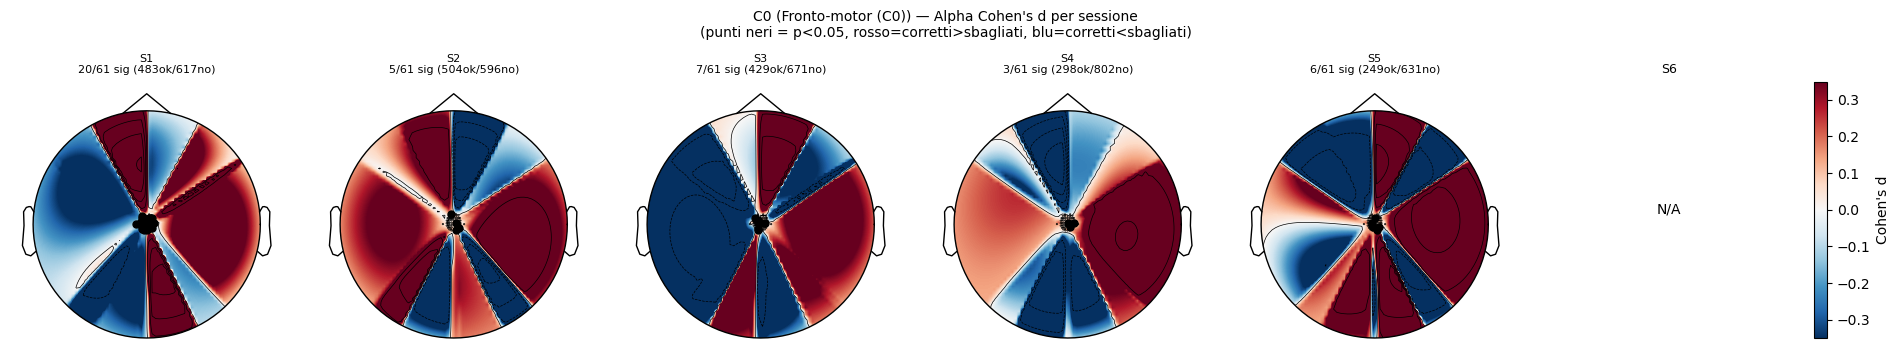

Salvato: eeg22v2_topomap_C0_alpha_per_session.png


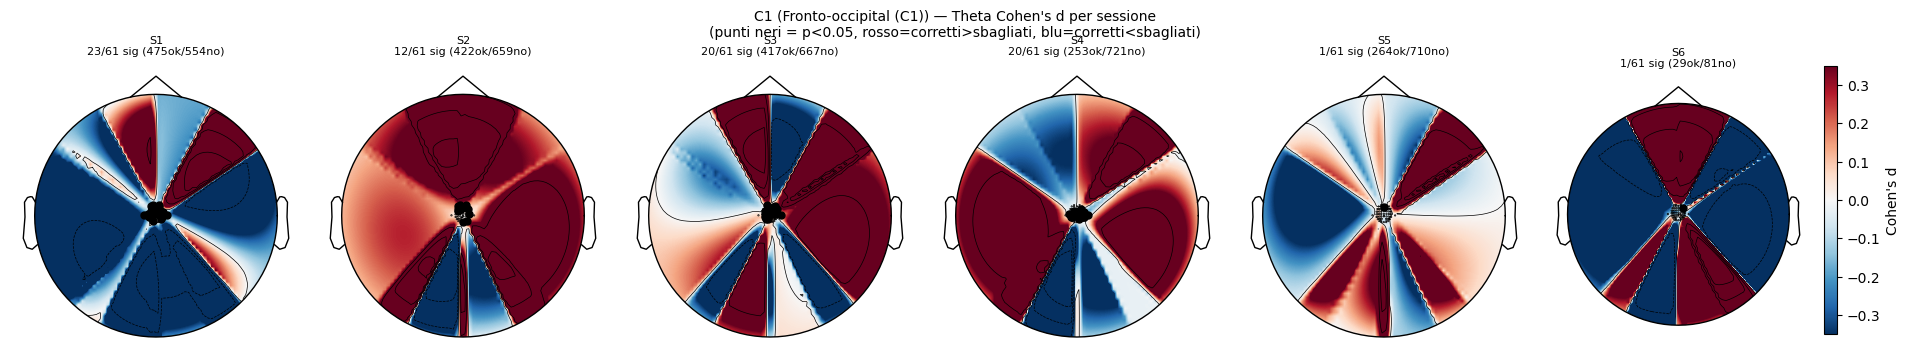

Salvato: eeg22v2_topomap_C1_theta_per_session.png


In [10]:
# §9 — Topomap per sessione (C0 alpha / C1 theta)
import mne
from scipy.stats import mannwhitneyu as _mwu

# Build MNE info (ebneuro montage)
_info = mne.create_info(ch_names=CHAN_NAMES_MNE, sfreq=FS, ch_types='eeg')
_montage = mne.channels.make_standard_montage('standard_1020')
_keep = [ch for ch in CHAN_NAMES_MNE if ch in _montage.ch_names]
try:
    _info.set_montage(_montage, on_missing='ignore')
except Exception:
    pass

HEAD_SCALE = 1.15

def cohd_pval_per_elec(records, cluster_id, band, sess_id):
    """Returns (cohd_array [61], pval_array [61]) for given cluster/band/session."""
    recs = [r for r in records if r['subj_id'] in
            [s for s, c in SUBJ_CLUSTER.items() if c == cluster_id]
            and r['sess_id'] == sess_id]
    ok  = [r for r in recs if r['correct'] == 1]
    no  = [r for r in recs if r['correct'] == 0]
    if len(ok) < 5 or len(no) < 5:
        return None, None
    bp_ok = np.stack([r['bp'][band] for r in ok])   # (n_ok, 61)
    bp_no = np.stack([r['bp'][band] for r in no])   # (n_no, 61)
    cd = np.zeros(N_CHANNELS); pv = np.ones(N_CHANNELS)
    for ch in range(N_CHANNELS):
        _, p = _mwu(bp_ok[:, ch], bp_no[:, ch], alternative='two-sided')
        pv[ch] = p
        ps = np.sqrt((bp_ok[:, ch].std()**2 + bp_no[:, ch].std()**2) / 2 + 1e-12)
        cd[ch] = (bp_ok[:, ch].mean() - bp_no[:, ch].mean()) / ps
    return cd, pv

# Plot grid: 2 rows (C0, C1) × n_sess cols
BAND_CL = {0: 'alpha', 1: 'theta'}
VLIM = 0.35

for cl in [0, 1]:
    band = BAND_CL[cl]
    sess_list = sorted(SESS_RESULTS[cl].keys())
    n_sess = len(sess_list)
    fig, axes = plt.subplots(1, n_sess, figsize=(3.2 * n_sess, 3.5))
    fig.patch.set_facecolor('white')
    if n_sess == 1: axes = [axes]

    for ax, sess_id in zip(axes, sess_list):
        cd, pv = cohd_pval_per_elec(ALL_SESS_RECORDS, cl, band, sess_id)
        if cd is None:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center', transform=ax.transAxes)
            ax.axis('off')
            ax.set_title(f'S{sess_id}', fontsize=9)
            continue

        # mask: non-significant → show faint
        mask = pv < 0.05
        cd_masked = cd.copy()

        nsig = int(mask.sum())
        recs_sess = [r for r in ALL_SESS_RECORDS
                     if SUBJ_CLUSTER.get(r['subj_id']) == cl and r['sess_id'] == sess_id]
        n_ok = sum(1 for r in recs_sess if r['correct'] == 1)
        n_no = sum(1 for r in recs_sess if r['correct'] == 0)

        im, _ = mne.viz.plot_topomap(
            cd_masked, _info, axes=ax,
            cmap='RdBu_r', vlim=(-VLIM, VLIM),
            mask=mask, mask_params=dict(marker='o', markerfacecolor='k',
                                         markeredgecolor='k', markersize=5, linewidth=0),
            show=False, sphere=HEAD_SCALE
        )
        ax.set_title(f'S{sess_id}\n{nsig}/61 sig ({n_ok}ok/{n_no}no)', fontsize=8, color='black')

    plt.colorbar(im, ax=axes[-1], fraction=0.046, pad=0.04, label="Cohen's d")
    cl_name = CLUSTER_NAMES[cl]
    plt.suptitle(f'C{cl} ({cl_name}) — {band.capitalize()} Cohen\'s d per sessione\n'
                 f'(punti neri = p<0.05, rosso=corretti>sbagliati, blu=corretti<sbagliati)',
                 fontsize=10, color='black')
    plt.tight_layout()
    fname = FIG_DIR / f'eeg22v2_topomap_C{cl}_{band}_per_session.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'Salvato: {fname.name}')
